# Example of Derived Data Streams
This notebook presents examples of creating data streams that are not the native data product but are derived from them. 

In [1]:
import os,sys
sys.path.append(os.path.join(os.getcwd(),"../"))
from nasctn_sea_visualization import *
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.dates as mdates
import pandas as pd



Importing nasctn_sea_visualization.data_models
It took 1.493138 s to import nasctn_sea_visualization.data_models
Importing nasctn_sea_visualization.plotters


It took 2.608682 s to import nasctn_sea_visualization.plotters
It took 4.10182 s to import all of the active modules


# Function Definition 

In [74]:
def read_psd(loc):
    """reads in a PSD csv file and formats the index and columns appropriately."""
    dat=pd.read_csv(loc,index_col = 0)
    dat.index = pd.to_datetime(dat.index.values)
    dat.columns = dat.columns.values.astype('float')/1e6
    return dat
def corr_coeff_window(x,r,windowsize = 28):
    start_int = windowsize-1
    xr = norm(x).rolling(window=windowsize).max()[start_int:]
    rr = r.rolling(window=windowsize).max()[start_int:]
    correlation = signal.correlate(rr-np.mean(rr),xr-np.mean(xr))
    lag = correlation.argmax()-(len(rr) - 1)
    x_corrected = np.roll(x,lag)
    return x_corrected
#Reference Waveform Build 
# this is based on LTE config 2, special config 7 as per dhagle.in/LTE
a = np.append(np.ones(3*14*4+10*4),np.zeros(4*4+14*4))
lte27=pd.Series(np.roll(np.append(a,a),167))
def channel_sensor_day_analysis_plot(sensor_name,date,channel,summary,**options):
    """Generates a multi-panel analysis plot for a given sensor_name,date,channel (MHz) in summary dataframe.
    Additional options can be passed in as keyword arguments to override defaults.  """ 
    defaults = {"top_directory":r"Y:\Tier2",
                "psd_stream":"max","cmap":"hot","psd_vmax":None,"psd_vmin":None,"pfp_vmin":None,"pfp_vmax":None,
                "pfp_detector":"peak","pfp_statistic":"max","save":False,"show":False,"title":False,
                "figsize":(15,10),"axline_color":"blue",
                "minute_locator_interval":15,
                "hour_locator_interval":1,
                "fontsize":14,"timeformat":"%H",
                "linestyle":"dashed","alpha_interval":.7,"ylabel":False,"legend":False}
    plot_options ={}

    for key,value in defaults.items():
        plot_options[key] = value

    for key,value in options.items():
        plot_options[key] = value
    frequency_mhz=channel
    selected_data = summary[summary["sensor_name"]==sensor_name]
    selected_data = selected_data[selected_data["date"]==date]
    selected_data = selected_data[selected_data["channel_frequency_mhz"]==frequency_mhz]
    data_table = read_psd(os.path.join(plot_options["top_directory"],
                                       "PSD",
                                       f"{date}_{sensor_name}_{plot_options['psd_stream']}.csv"))

    #data ingest
    pfp_path = os.path.join(plot_options["top_directory"],
                            "PFP Aligned",
                            f"PFP_{date}_{sensor_name}_{plot_options['pfp_statistic']}_{plot_options['pfp_detector']}.csv")
    frequency_hz = channel*1e6
    pfp_df= pd.read_csv(pfp_path,index_col=0)
    pfp_df.index = pd.to_datetime(pfp_df.index)
    #data selection
    x_data = np.linspace(0,10,560)
    selected_pfp_data = pfp_df[pfp_df["frequency"]==frequency_hz]
    selected_pfp_data = selected_pfp_data.drop("frequency",axis=1)    
    indexes  = [i for i in range(0,95)]+ [i for i in range(175,375)]+ [i for i in range(450,560)]
    c_indexes = [i for i in range(95,175)]+ [i for i in range(375,450)]
    base_date = data_table.index[20].date()
    start_midnight = datetime.datetime.combine(base_date, datetime.time(0, 0, 0))
    end_midnight = datetime.datetime.combine(base_date + datetime.timedelta(days=1), datetime.time(0, 0, 0))
    date_formatter = mdates.DateFormatter(plot_options["timeformat"])
    minor_locator = mdates.MinuteLocator(interval=plot_options["minute_locator_interval"])
    major_locator = mdates.HourLocator(interval=plot_options['hour_locator_interval'])

    # plotting
    plt.rcParams.update({"font.size":plot_options["fontsize"]})
    fig, ax = plt.subplots(nrows=5,sharex=True,figsize=plot_options["figsize"])
    selected_pfp_data=selected_pfp_data.T.apply(lambda x: corr_coeff_window(x,lte27)).T
    selected_data = summary[summary["sensor_name"]==sensor_name]
    selected_data = selected_data[selected_data["date"]==date]
    selected_data = selected_data[selected_data["channel_frequency_mhz"]==frequency_mhz]
    selected_data["timestamp"] = pd.to_datetime(selected_data["timestamp"])
    psd_indices = [a for a in data_table.columns if (frequency_mhz-5<a)&(a<frequency_mhz+5)]
    selected_psd  = data_table[psd_indices]
    ########################################################
    ax[0].pcolormesh(data_table.index.values,data_table.columns.values,data_table.T,cmap=plot_options["cmap"],vmin=plot_options["psd_vmin"],vmax=plot_options["psd_vmax"])
    ax[0].set_ylim([frequency_mhz-5,frequency_mhz+5])
    if plot_options["ylabel"]:
        ax[0].set_ylabel("Frequency \n(MHz)")
    ###################################################
    ax[1].plot(selected_psd.index.values,selected_psd.T.std())
    if plot_options["ylabel"]:
        ax[1].set_ylabel("STD (dB)")
    
    ##############################################################
    ax[2].plot(selected_data["timestamp"],selected_data["max"]-selected_data["median"],label="PMPR")
    ax[2].plot(selected_data["timestamp"],selected_data["mean"]-selected_data["median"],label="AMPR")
    ax[2].grid()
    if plot_options["ylabel"]:
        ax[2].set_ylabel("Ratio (dB)")
    if plot_options["legend"]:
        ax[2].legend()
    ##############################################################
    colormesh = ax[3].pcolormesh(selected_pfp_data.index,x_data,selected_pfp_data.T,cmap=plot_options["cmap"],vmin=plot_options["pfp_vmin"],vmax=plot_options["pfp_vmax"])
    if plot_options["ylabel"]:
        ax[3].set_ylabel("Time (ms)")
    ################################################################
    ax[4].plot(selected_pfp_data.index,selected_pfp_data.T.std(),label="PFP STD")
    ax[4].plot(selected_pfp_data.index,selected_pfp_data.iloc[:,indexes].std(axis=1),label="DL STD")
    ax[4].plot(selected_pfp_data.index,selected_pfp_data.iloc[:,c_indexes].std(axis=1),label="UL STD")
    if plot_options["legend"]:
        ax[4].legend()
    if plot_options["ylabel"]:
        ax[4].set_ylabel("STD (dB)")
    ax[4].set_xlabel ("Time (UTC)")
    for a in ax:
        a.set_xlim(start_midnight, end_midnight)
        a.xaxis.set_minor_locator(minor_locator)
        a.xaxis.set_major_locator(major_locator)
        a.xaxis.set_major_formatter(date_formatter)
        for m in a.get_xticks():
            a.axvline(m,color=plot_options["axline_color"],alpha=plot_options["alpha_interval"],
                      linestyle=plot_options["linestyle"])
    plt.suptitle(f"{sensor_name}:{frequency_mhz:4.0f} MHz on {date}")

    if plot_options["title"]:
        ax[3].set_title(f"PFP:{plot_options['pfp_detector'].capitalize()}-{plot_options['pfp_statistic'].capitalize()}")
        ax[4].set_title("PFP,UL and DL STD")
        ax[2].set_title("Summary PMPR and AMPR")
        ax[0].set_title(f"PSD:{plot_options['psd_stream'].capitalize()} ")
        ax[1].set_title(f"PSD STD")
        plt.tight_layout()
    if plot_options["save"]:
        plt.savefig(plot_options["save"])
    if plot_options["show"]:
        plt.show()

def training_plot(sensor_name,date,training_directory=r"Z:\personal_scratch\aric_sanders\Training Data",**Options):
    """This plots values from a pre-computed file with column names "PMPR","MMPR","psd_std","pfp_std","dl_std","ul_std" """
    defaults = {"save":False,"show":False,"title":True,
                "figsize":(15,10),
                "minute_locator_interval":15,
                "hour_locator_interval":1,
                "fontsize":14,"timeformat":"%H",
                "colorbar":True,"cmap":"hot"}
    plot_options ={}

    for key,value in defaults.items():
        plot_options[key] = value

    for key,value in options.items():
        plot_options[key] = value
    date_formatter = mdates.DateFormatter(plot_options["timeformat"])
    minor_locator = mdates.MinuteLocator(interval=plot_options["minute_locator_interval"])
    major_locator = mdates.HourLocator(interval=plot_options['hour_locator_interval'])
    month = "_".join(date.split("-")[0:2])
    training_path = os.path.join(training_directory,month,f"training_data_{sensor_name}_{date}.csv")
    training_data = pd.read_csv(training_path)
    training_data["timestamps"] = pd.to_datetime(training_data["timestamps"])
    plt.rcParams.update({"font.size":plot_options["fontsize"]})
    figure,axs = plt.subplots(ncols = 3,nrows = 2,figsize=plot_options["figsize"],sharey=True,sharex=True)
    axs= axs.flatten()
    labels = ["PMPR","AMPR","PSD STD","PFP STD","DL STD","UL STD"]
    colorbar_labels = ["Ratio (dB)","Ratio(dB)","STD (dB)","STD (dB)","STD (dB)","STD (dB)"]
    for i,feature in enumerate(["PMPR","MMPR","psd_std","pfp_std","dl_std","ul_std"]):
        pivot = training_data.pivot(index="timestamps",
                                    columns="channel", values=feature)
        colormesh=axs[i].pcolormesh(pivot.columns,pivot.index,pivot.values,
                             rasterized=True,cmap=plot_options["cmap"])
        axs[i].set_title(f"{labels[i]}")
        if plot_options["colorbar"]:
            figure.colorbar(colormesh, ax=axs[i],label=colorbar_labels[i])
        if i>2:
            axs[i].set_xlabel("Frequency (MHz)")
            axs[i].tick_params(axis='x', rotation=60)

    axs[0].yaxis.set_minor_locator(minor_locator)
    axs[0].yaxis.set_major_locator(major_locator)
    axs[0].yaxis.set_major_formatter(date_formatter)
    axs[0].set_ylabel("Time (UTC)")
    if plot_options["title"]:
        figure.suptitle(f"{sensor_name} on {date}")
        #plt.colorbar(colormesh,ax=axs[i],label=feature) 
    if plot_options["save"]:
        plt.savefig(plot_options["save"])
    if plot_options["show"]:
        plt.show()
    plt.tight_layout()


## Data Ingest

In [ ]:
# Update path to your copy or https://data.nist.gov/od/ds/mds2-4214/Summaries/2025_03.csv
march_2025_summary = pd.read_csv(r"Y:\Tier2\Summaries\2025_03.csv")

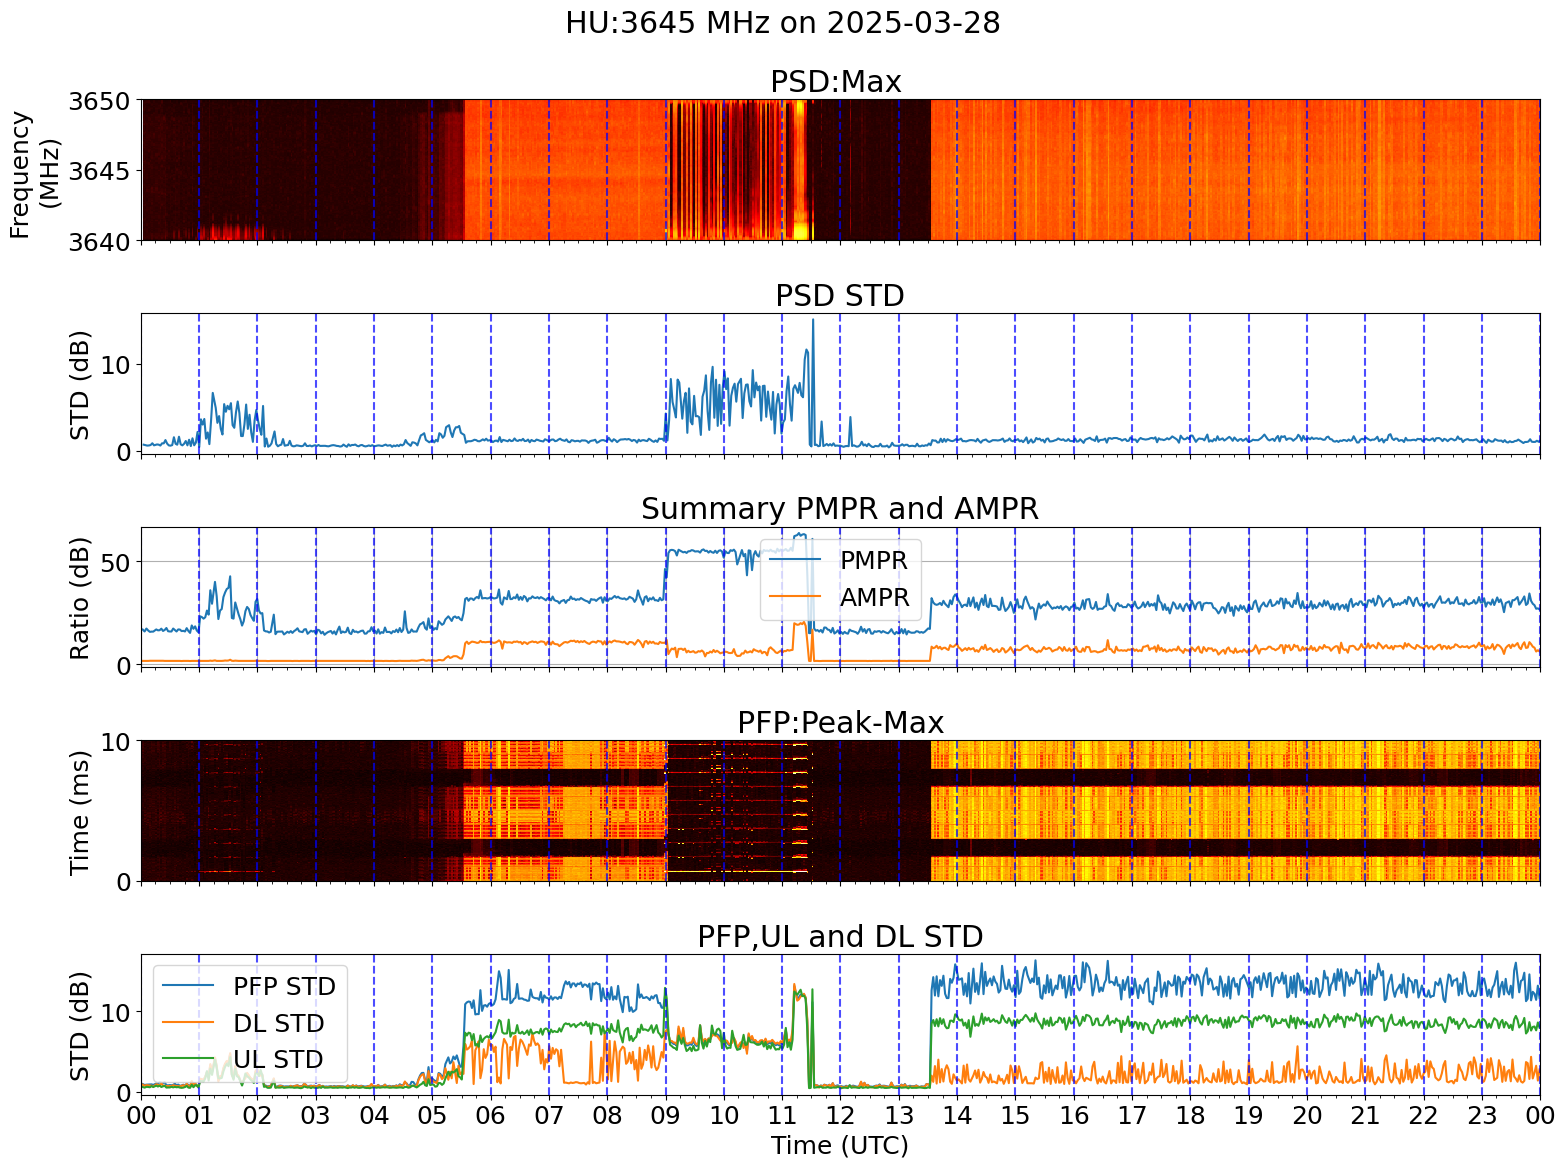

In [59]:
frequency = 3645
date = "2025-03-28"
options ={"top_directory":r"Y:\Tier2",
                "psd_stream":"max","cmap":"hot","psd_vmax":None,"psd_vmin":None,"pfp_vmin":None,"pfp_vmax":None,
                "pfp_detector":"peak","pfp_statistic":"max","save":False,"show":False,"title":True,
                "figsize":(16,12),"axline_color":"blue",
                "minute_locator_interval":15,
                "hour_locator_interval":1,
                "fontsize":18,"timeformat":"%H",
                "linestyle":"dashed","alpha_interval":.7,"ylabel":True,"legend":True}
channel_sensor_day_analysis_plot(sensor_name="HU",date=date,channel=frequency,summary=march_2025_summary,**options)

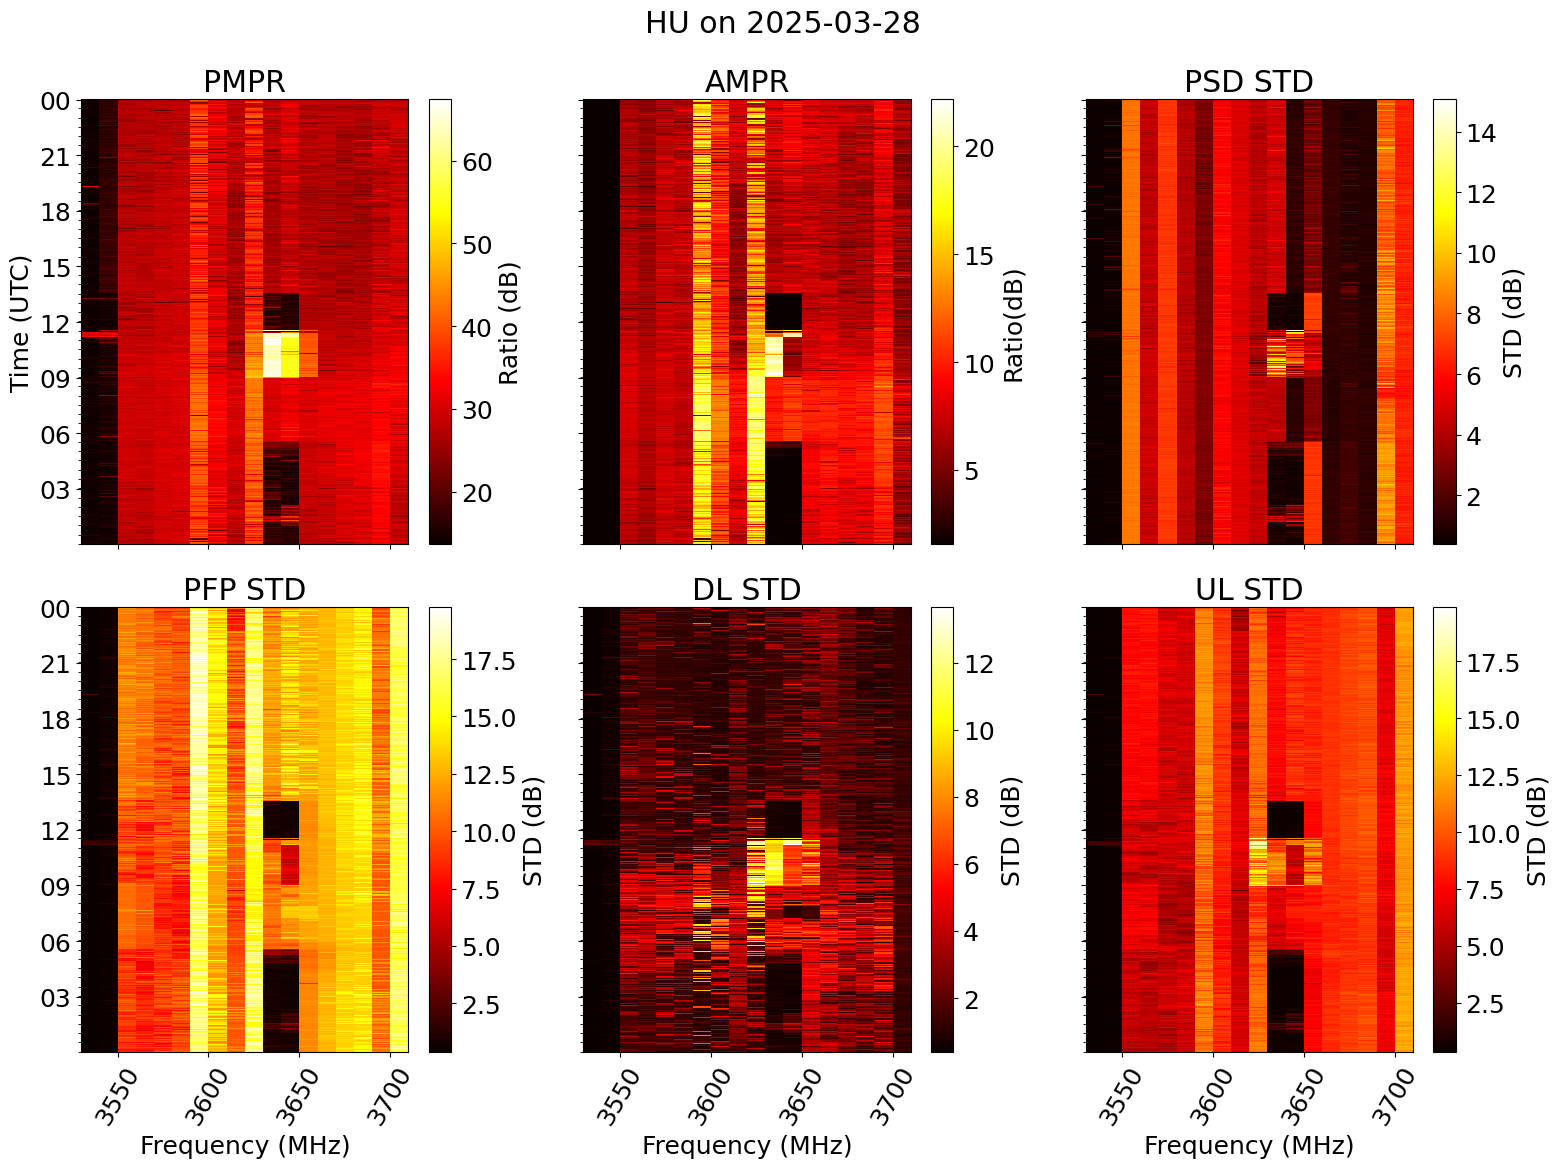

In [75]:
options = {"save":False,"show":False,"title":True,
                "figsize":(16,12),
                "minute_locator_interval":30,
                "hour_locator_interval":3,
                "fontsize":18,"timeformat":"%H"}
training_plot("HU",date,training_directory=r"\\ontario-smb.nist.gov\ctl\675\675-01\personal_scratch\aric_sanders\Training Data")